License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


# PBR Energy Balance Example

This notebook mirrors the style of the Fogler P13-7 notebook and walks through a reversible reaction in a packed-bed reactor with pressure drop and heat effects.

## Why Are We Learning This?

The method of heat transfer influences PFR performance, sometimes substantially. This example both illustrates that and provides conversion and temperature profile plots that can be used to visualize and explain how heat transfer influences reactor performance.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

## Problem Data

In [ ]:
FA0=5
FB0=2*FA0
FI=FB0
CA0=0.2
T0=325
Ta0=300
CPA=0.020
CPB=CPA
CPC=CPA
CPI=CPA
CPcoolant=0.018
E=25
DHrxn=-20
k_ref=0.0002
T_kref=300
alpha=0.00015
Ua=0.00032
mdotc=18
rho_b=1.4
KC_ref=1000
T_KCref=305
R=0.001987
thetaB=FB0/FA0
thetaI=FI/FA0
W=np.linspace(0,5000)

From this data, $\Delta C_P = 0$.

## Step 1: Mole Balance
For a PBR:

$$\frac{dX}{dW}=\frac{-r_A'}{F_{A0}}$$

## Step 2: Concentration Equations
For A + B $\leftrightharpoons$ 2C with $\Theta_B = 2$ and no net change in moles ($\delta = 0$) being carried out in the gas phase with pressure drop in a non-isothermal flow reactor:

$$C_A=C_{A0}(1-X)\frac{T_0}{T}p$$

$$C_B=C_{A0}(\Theta_B-X)\frac{T_0}{T}p$$

where

$$p = \frac{P_T}{P_{T0}}$$

Since there is pressure drop, we need to include the Ergun equation:

In [ ]:
def CA(X,T,p):
  return CA0*(1-X)*(T0/T)*p

def CB(X,T,p):
  return CA0*(thetaB-X)*(T0/T)*p

def CC(X,T,p):
  return CA0*X*(T0/T)*p

## Step 3: Arrhenius Equation

In [ ]:
def kf(T):
    return k_ref*np.exp(E/R*(1/T_kref-1/T))

## Step 4: van't Hoff Equation

In [ ]:
def Kc(T):
    return KC_ref*np.exp((-DHrxn/R)*(1/T-1/T_KCref))

## Step 5: Rate Law

In [ ]:
def rate(X,T,p):
    return -kf(T)*(CA(X,T,p)*CB(X,T,p) - CC(X,T,p)**2/Kc(T))

## Step 6: Derive Equilibrium Conversion
Equilibrium constant:

$$ K_C = \frac{C_{C,e}^2}{C_{A,e}C_{B,e}} $$

where

$$C_{A,e}=C_{A0}(1-X_e)\frac{T_0}{T}p$$

$$C_{B,e}=C_{A0}\left(\Theta_B-X_e\right)\frac{T_0}{T}p$$

and

$$C_{C,e}=C_{A0}X_e\frac{T_0}{T}p$$

therefore:

$$ K_C = \frac{C_{A0}^2X_e^2\left(\frac{T_0}{T}\right)^2p^2}{\left(C_{A0}(1-X_e)\frac{T_0}{T}p\right)\left(C_{A0}\left(\Theta_B-X_e\right)\frac{T_0}{T}p\right)} $$

Simplifying:

$$ K_C = \frac{C_{A0}^2X_e^2\left(\frac{T_0}{T}\right)^2p^2}{C_{A0}^2\left(\frac{T_0}{T}\right)^2p^2\left(1-X_e\right)\left(\Theta_B-X_e\right)} $$

so

$$ K_C = \frac{X_e^2}{\left(1-X_e\right)\left(\Theta_B-X_e\right)} $$


We must use the quadratic formula to solve for $X_e$. First set up the equation accordingly:

$$ K_C\left(1-X_e\right)\left(\Theta_B-X_e\right) = X_e^2$$

$$ K_C\left(\Theta_B-X_e\left(1+\Theta_B\right)+X_e^2\right) = X_e^2$$

$$ K_C\Theta_B -X_e K_C (1+\Theta_B)+X_e^2(K_C-1) = 0$$

Hence:

$$a = K_C-1 $$

$$b = -K_C (1+\Theta_B) $$

$$c = K_C\Theta_B $$

In [ ]:
def Xe(Kc, Theta_B):
  a = Kc - 1
  b = -Kc * (1 + Theta_B)
  c = Kc * Theta_B

  discriminant = b**2 - 4*a*c

  root1 = (-b + np.sqrt(discriminant)) / (2 * a)
  root2 = (-b - np.sqrt(discriminant)) / (2 * a)

  condition = (root1 >= 0) & (root1 <= 1)
  actual_Xe = np.where(condition, root1, root2)

  return actual_Xe

## Constant-Ta Case

In [ ]:
Ta=Ta0
def constTa(W,y):
    X,T,p=y
    r=rate(X,T,p)
    dpdW=-alpha/(2*p)*T/T0
    dXdW=-r/FA0
    dTdW=(r*DHrxn+(Ua/rho_b)*(Ta-T))/(FA0*(CPA+thetaB*CPB+thetaI*CPI))
    return [dXdW,dTdW,dpdW]

In [ ]:
x0=0
p0=1
sol_constTa=solve_ivp(constTa,[0,W[-1]],[x0,T0,p0],t_eval=W,method='Radau')
W=sol_constTa.t
X_constTa=sol_constTa.y[0]
T_constTa=sol_constTa.y[1]
p_constTa=sol_constTa.y[2]
KC_constTa=Kc(T_constTa)
Xe_constTa=Xe(KC_constTa,thetaB)

### Plots

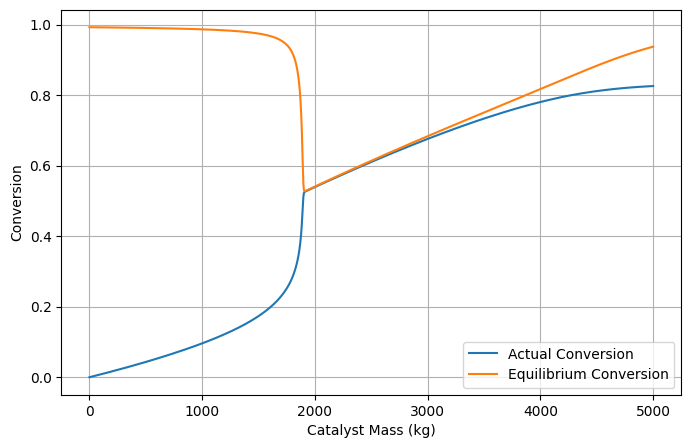

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,X_constTa,label="Actual Conversion")
plt.plot(W,Xe_constTa,label="Equilibrium Conversion")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

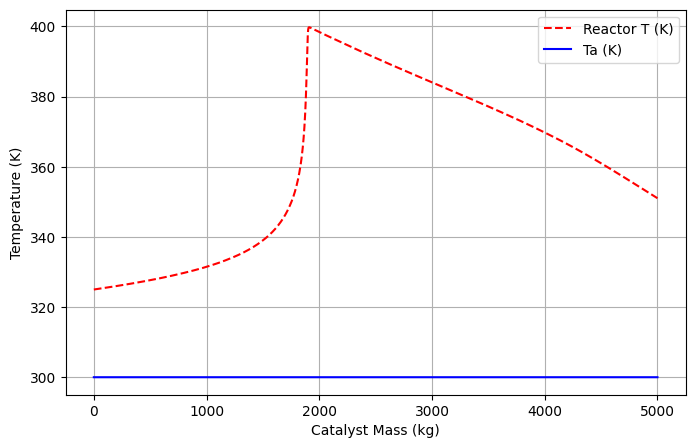

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,T_constTa,"r--",label="Reactor T (K)")
plt.plot(W,Ta*np.ones_like(T_constTa),"b-",label="Ta (K)")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid()
plt.show()

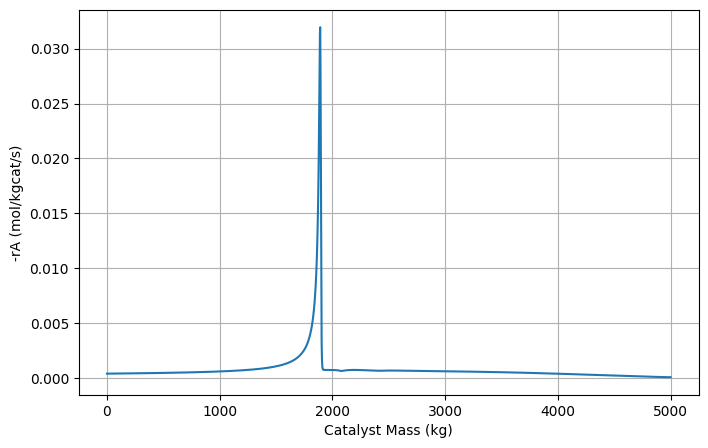

In [ ]:
r_profile_constTa=-rate(X_constTa,T_constTa,p_constTa)
plt.figure(figsize=(8,5))
plt.plot(W,r_profile_constTa)
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("-rA (mol/kgcat/s)")
plt.grid()
plt.show()

### Reactor Exit and Max Temp

In [ ]:
print("Exit Conversion:",X_constTa[-1])
print("Exit Temperature (K):",T_constTa[-1])
print("Exit Equilibrium Conversion:",Xe_constTa[-1])
print("Fraction of Equilibrium Achieved:",X_constTa[-1]/Xe_constTa[-1])
print("Maximum Temperature (K):",np.max(T_constTa))

Exit Conversion: 0.8257367619765511
Exit Temperature (K): 351.0236156717432
Exit Equilibrium Conversion: 0.9373934951188745
Fraction of Equilibrium Achieved: 0.8808859526722407
Maximum Temperature (K): 399.76830846102774


## Adiabatic Case

In [ ]:
def T_ad(X):
  return T0+(-DHrxn*X)/(CPA+thetaB*CPB+thetaI*CPI)

def adiabatic(W,y):
    X,p=y
    T = T_ad(X)
    dpdW=-alpha/(2*p)*T/T0
    r=rate(X,T,p)
    dXdW=-r/FA0
    return [dXdW,dpdW]

In [ ]:
sol_ad=solve_ivp(adiabatic,[0,W[-1]],[x0,p0],t_eval=W,method='Radau')
V=sol_ad.t
X_ad=sol_ad.y[0]
p_ad=sol_ad.y[1]
T_ad_plot=T_ad(X_ad)
KC_ad=Kc(T_ad_plot)
Xe_ad=Xe(KC_ad,thetaB)

### Plots:

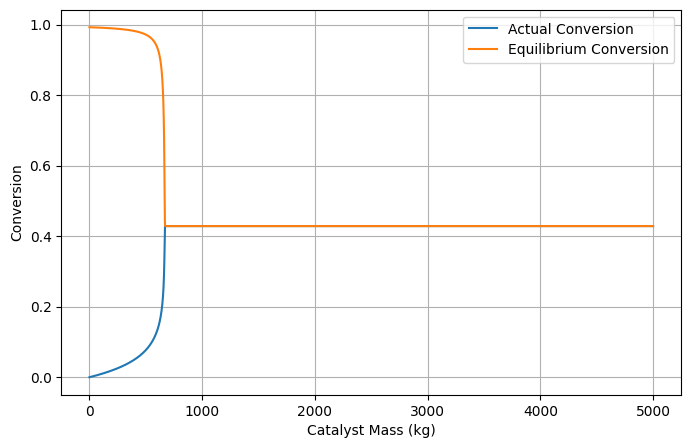

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,X_ad,label="Actual Conversion")
plt.plot(V,Xe_ad,label="Equilibrium Conversion")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

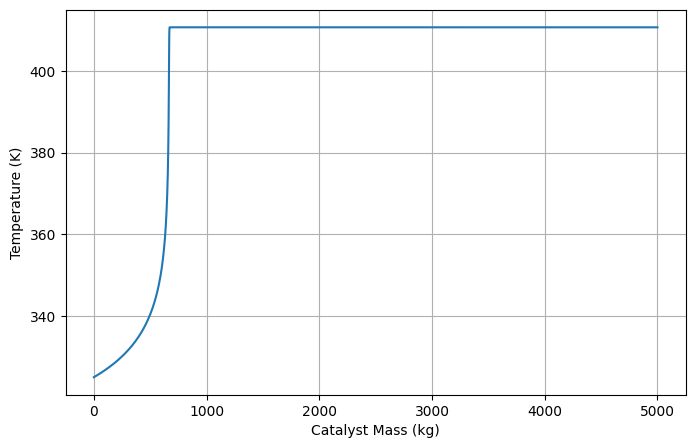

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(V,T_ad_plot)
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Temperature (K)")
plt.grid()
plt.show()

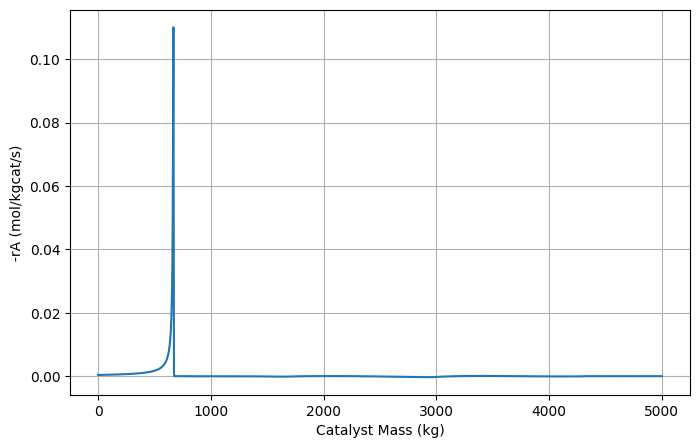

In [ ]:
r_profile_ad=-rate(X_ad,T_ad_plot,p_ad)
plt.figure(figsize=(8,5))
plt.plot(V,r_profile_ad)
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("-rA (mol/kgcat/s)")
plt.grid()
plt.show()

### Exit Conditions and Max Temp

In [ ]:
print("Exit Conversion:",X_ad[-1])
print("Exit Temperature (K):",T_ad_plot[-1])
print("Exit Equilibrium Conversion:",Xe_ad[-1])
print("Fraction of Equilibrium Achieved:",X_ad[-1]/Xe_ad[-1])
print("Maximum Temperature (K):",np.max(T_ad_plot))

Exit Conversion: 0.4281927921012373
Exit Temperature (K): 410.6385584202475
Exit Equilibrium Conversion: 0.42927604656069807
Fraction of Equilibrium Achieved: 0.9974765550788597
Maximum Temperature (K): 410.79294039094873


## Co-current Heat Exchanger

In [ ]:
def cocurrent(W,y):
    X,T,p,Ta=y
    r=rate(X,T,p)
    dXdW=-r/FA0
    dpdW=-alpha/(2*p)*T/T0
    dTdW=(r*DHrxn+(Ua/rho_b)*(Ta-T))/(FA0*(CPA+thetaB*CPB+thetaI*CPI))
    dTadW=(Ua/rho_b)*(T-Ta)/(mdotc*CPcoolant)
    return [dXdW,dTdW,dpdW,dTadW]

In [ ]:
sol_cocurr=solve_ivp(cocurrent,[0,W[-1]],[x0,T0,p0,Ta0],t_eval=W,method='Radau')
W=sol_cocurr.t
X_cocurr=sol_cocurr.y[0]
T_cocurr=sol_cocurr.y[1]
p_cocurr=sol_cocurr.y[2]
Ta_cocurr=sol_cocurr.y[3]
KC_cocurr=Kc(T_cocurr)
Xe_cocurr=Xe(KC_cocurr,thetaB)

### Plots

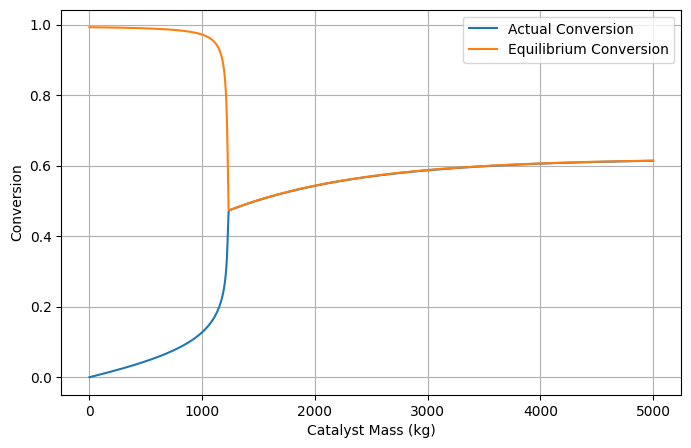

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,X_cocurr,label="Actual Conversion")
plt.plot(W,Xe_cocurr,label="Equilibrium Conversion")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

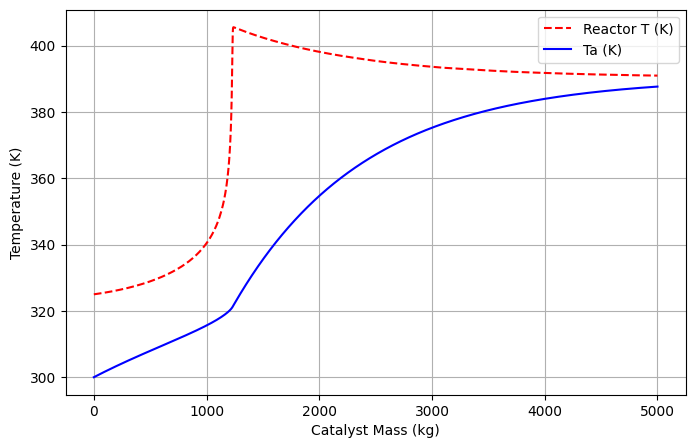

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,T_cocurr,"r--",label="Reactor T (K)")
plt.plot(W,Ta_cocurr,"b-",label="Ta (K)")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid()
plt.show()

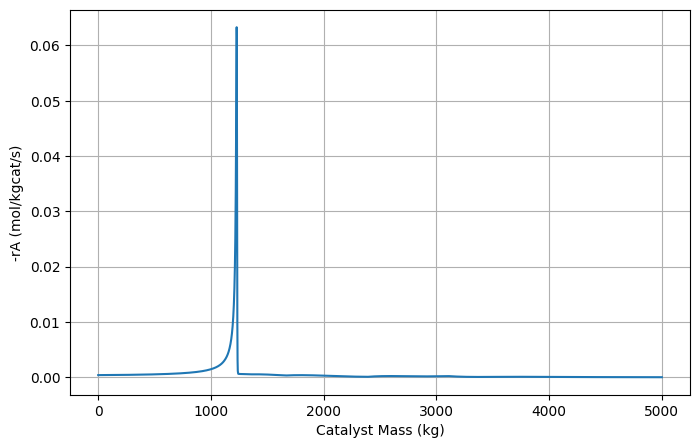

In [ ]:
r_profile_cocurr=-rate(X_cocurr,T_cocurr,p_cocurr)
plt.figure(figsize=(8,5))
plt.plot(W,r_profile_cocurr)
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("-rA (mol/kgcat/s)")
plt.grid()
plt.show()

### Reactor Exit Conditions and Max Temp

In [ ]:
print("Exit Conversion:",X_cocurr[-1])
print("Exit Temperature (K):",T_cocurr[-1])
print("Exit Equilibrium Conversion:",Xe_cocurr[-1])
print("Fraction of Equilibrium Achieved:",X_cocurr[-1]/Xe_cocurr[-1])
print("Maximum Temperature (K):",np.max(T_cocurr))

Exit Conversion: 0.6137679572027295
Exit Temperature (K): 390.95788156184864
Exit Equilibrium Conversion: 0.6142944661240154
Fraction of Equilibrium Achieved: 0.999142904664911
Maximum Temperature (K): 405.54956621376385


## Counter-current Heat Exchanger

In [ ]:
def countercurrent(W,y):
    X,T,p,Ta=y
    r=rate(X,T,p)
    dXdW=-r/FA0
    dpdW=-alpha/(2*p)*T/T0
    dTdW=(r*DHrxn+(Ua/rho_b)*(Ta-T))/(FA0*(CPA+thetaB*CPB+thetaI*CPI))
    dTadW=-(Ua/rho_b)*(T-Ta)/(mdotc*CPcoolant)
    return [dXdW,dTdW,dpdW,dTadW]

In [ ]:
def objective(Ta0_guess):
  y0 = [x0, T0, p0, Ta0_guess]
  sol =solve_ivp(countercurrent,[0,W[-1]],y0,t_eval=W,method='Radau')
  Ta_final = sol.y[3, -1]
  return Ta_final - Ta0

In [ ]:
result = root_scalar(objective, bracket=[300, 400], method="brentq")
optimal_Ta0 = result.root

In [ ]:
sol_counter =solve_ivp(countercurrent,[0,W[-1]],[x0,T0,p0,optimal_Ta0],t_eval=W,method='Radau')
W=sol_counter.t
X_counter=sol_counter.y[0]
T_counter=sol_counter.y[1]
p_counter=sol_counter.y[2]
Ta_counter=sol_counter.y[3]
KC_counter=Kc(T_counter)
Xe_counter=Xe(KC_counter,thetaB)

### Plots

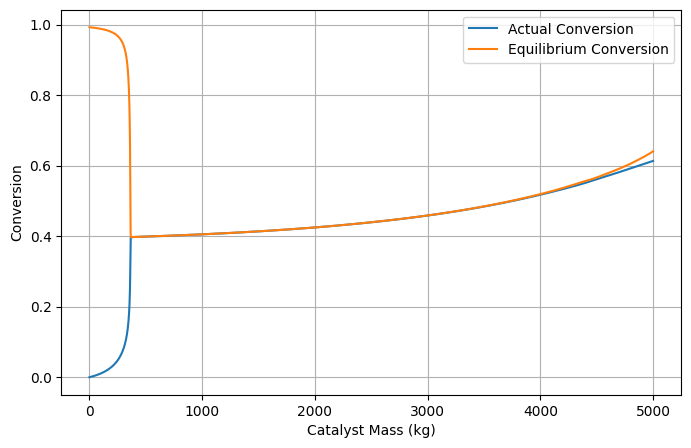

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,X_counter,label="Actual Conversion")
plt.plot(W,Xe_counter,label="Equilibrium Conversion")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Conversion")
plt.legend()
plt.grid()
plt.show()

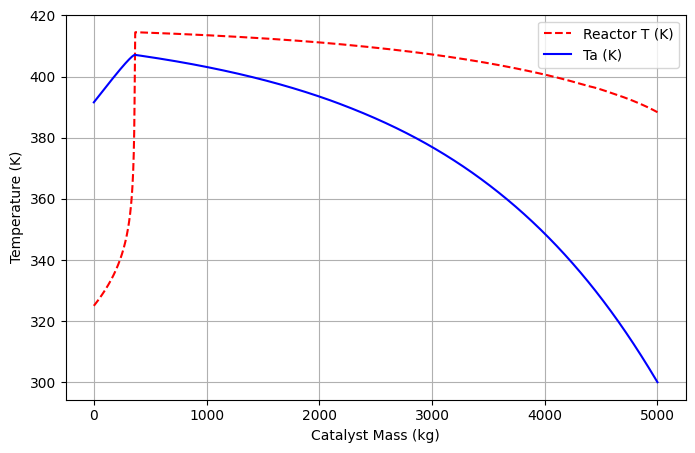

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,T_counter,"r--",label="Reactor T (K)")
plt.plot(W,Ta_counter,"b-",label="Ta (K)")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("Temperature (K)")
plt.legend()
plt.grid()
plt.show()

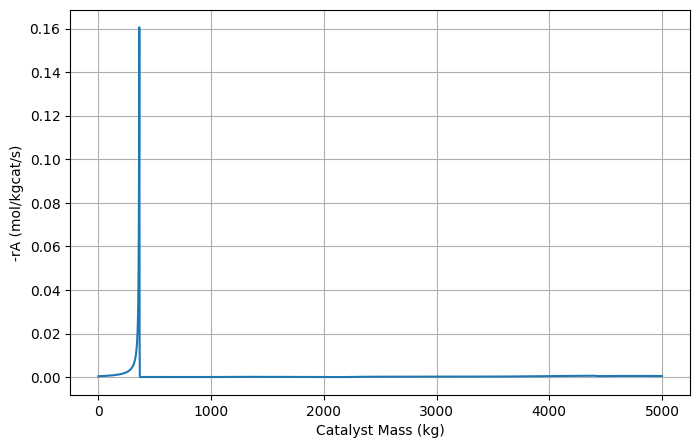

In [ ]:
r_profile_counter=-rate(X_counter,T_counter,p_counter)
plt.figure(figsize=(8,5))
plt.plot(W,r_profile_counter)
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("-rA (mol/kgcat/s)")
plt.grid()
plt.show()

### Reactor exit conditions and maximum T

In [ ]:
print("Exit Conversion:",X_counter[-1])
print("Exit Temperature (K):",T_counter[-1])
print("Exit Equilibrium Conversion:",Xe_counter[-1])
print("Fraction of Equilibrium Achieved:",X_counter[-1]/Xe_counter[-1])
print("Maximum Temperature (K):",np.max(T_counter))

Exit Conversion: 0.6133985109515585
Exit Temperature (K): 388.3434105237031
Exit Equilibrium Conversion: 0.6405491900204068
Fraction of Equilibrium Achieved: 0.957613436263992
Maximum Temperature (K): 414.512614708978


## Pressure Drop in all 4 scenarios

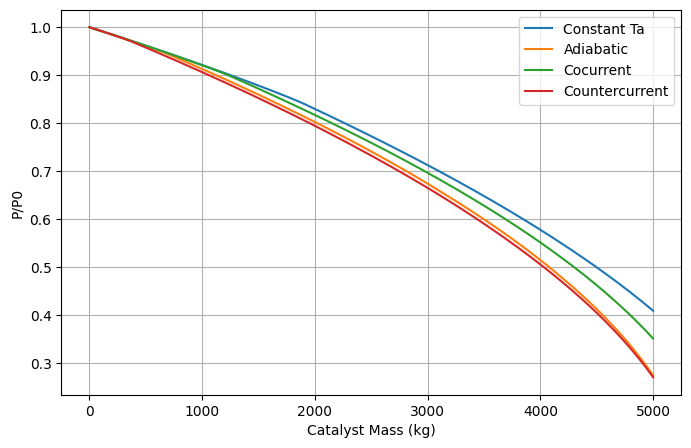

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(W,p_constTa,label="Constant Ta")
plt.plot(W,p_ad,label="Adiabatic")
plt.plot(W,p_cocurr,label="Cocurrent")
plt.plot(W,p_counter,label="Countercurrent")
plt.xlabel("Catalyst Mass (kg)")
plt.ylabel("P/P0")
plt.legend()
plt.grid()
plt.show()

Drag has a significant effect on pressure and hence concentration; this is exacerbated at higher temperature and hence in the heat exchange scenarios that lead to higher temperatures.